# SemMedDB Ingest Alignment Analysis

**Goal:** Analyze the current KG2 SemMedDB source data to align our ingest with BTE's approach,
working within the constraints of the KG2 pre-processed data.

**RTX-KG2 SemMedDB download (canonical):**  
`https://rtx-kg2-public.s3.us-west-2.amazonaws.com/kg2.10.3-semmeddb-edges.jsonl.gz`  
This is the same URL as `semmeddb/download.yaml` in translator-ingests (kghub-downloader / pipeline).

**Local file after ingest download:**  
`data/semmeddb/semmeddb-2023-kg2.10.3/source_data/kg2.10.3-semmeddb-edges.jsonl.gz`

**BTE reference notebook:** `BTE_semmeddb_analysis.ipynb` (in this directory).
Originally from: https://github.com/NCATS-Tangerine/translator-api-registry/blob/master/semmeddb/AutoGen_SEMMEDDB.ipynb

**Decisions from DINGO call**
- Pass through qualifier fields as-is from KG2 (don't remap activity vs activity_or_abundance)
- Rely on `domain_range_exclusion` to handle problematic cases
- Align predicate mappings with BTE as much as possible
- Work with what KG2 gives us rather than full re-ingest

**Sections:**
1. [Setup and Data Loading](#1-setup-and-data-loading)
2. [Overview: Record Count and Fields](#2-overview)
3. [Predicate Analysis: KG2 vs Our Ingest vs BTE](#3-predicate-analysis)
4. [Qualifier Field Coverage](#4-qualifier-field-coverage)
5. [Original SemMedDB Predicates (from kg2_ids)](#5-original-semmeddb-predicates)
6. [BTE Predicate Mapping Comparison](#6-bte-predicate-mapping-comparison)
7. [domain_range_exclusion Analysis](#7-domain-range-exclusion-analysis)
8. [Object Type Distribution per Predicate](#8-object-type-distribution)
9. [Publication Count Distribution](#9-publication-count-distribution)

## 1. Setup and Data Loading
<a id='1-setup-and-data-loading'></a>

In [2]:
import gzip
import json
import re
from collections import Counter, defaultdict
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# Public RTX-KG2 SemMedDB edges (matches semmeddb/download.yaml).
RTX_KG2_SEMMEDDB_URL = (
    "https://rtx-kg2-public.s3.us-west-2.amazonaws.com/kg2.10.3-semmeddb-edges.jsonl.gz"
)

SOURCE_FILE = Path(
    "../../../../data/semmeddb/semmeddb-2023-kg2.10.3/source_data/"
    "kg2.10.3-semmeddb-edges.jsonl.gz"
)

# Our current Koza YAML filter -- the 10 predicates we currently allow
CURRENT_INGEST_PREDICATES = {
    "biolink:treats_or_applied_or_studied_to_treat",
    "biolink:affects",
    "biolink:preventative_for_condition",
    "biolink:coexists_with",
    "biolink:causes",
    "biolink:related_to",
    "biolink:interacts_with",
    "biolink:located_in",
    "biolink:predisposes_to_condition",
    "biolink:disrupts",
}

print(f"RTX-KG2 download: {RTX_KG2_SEMMEDDB_URL}")
print(f"Local source file: {SOURCE_FILE}")
print(f"File exists: {SOURCE_FILE.exists()}")
print(f"Current ingest allows {len(CURRENT_INGEST_PREDICATES)} predicates")

Source file: ../../../../data/semmeddb/semmeddb-2023-kg2.10.3/source_data/kg2.10.3-semmeddb-edges.jsonl.gz
File exists: True
Current ingest allows 10 predicates


In [4]:
# Load all records once and collect stats in a single pass.
# This takes a few minutes for 21M records.

total_records = 0
all_fields = set()

biolink_predicate_counts = Counter()
original_predicate_counts = Counter()
qualifier_combos = Counter()
object_prefix_counts = Counter()
subject_prefix_counts = Counter()
pub_count_distribution = Counter()
domain_range_counts = Counter()

# Per original-predicate -> object prefix distribution
orig_pred_obj_prefix = defaultdict(Counter)

# Track records with/without qualifiers
records_with_qualifiers = 0
records_without_qualifiers = 0

# Per biolink predicate -> original predicate mapping
biolink_to_original = defaultdict(Counter)

print("Loading data (this may take a few minutes)...")

with gzip.open(SOURCE_FILE, "rt") as f:
    for line in f:
        rec = json.loads(line)
        total_records += 1
        all_fields.update(rec.keys())

        # Biolink predicate
        bl_pred = rec.get("predicate", "")
        biolink_predicate_counts[bl_pred] += 1

        # Original SemMedDB predicate from kg2_ids
        for kid in rec.get("kg2_ids", []):
            parts = kid.split("---")
            if len(parts) >= 2:
                orig_pred = parts[1].replace("SEMMEDDB:", "")
                original_predicate_counts[orig_pred] += 1
                biolink_to_original[bl_pred][orig_pred] += 1

                # Object prefix per original predicate
                obj = rec.get("object", "")
                obj_prefix = obj.split(":")[0] if ":" in obj else "unknown"
                orig_pred_obj_prefix[orig_pred][obj_prefix] += 1

        # Qualifier fields
        qp = rec.get("qualified_predicate")
        qa = rec.get("qualified_object_aspect")
        qd = rec.get("qualified_object_direction")
        if qp or qa or qd:
            records_with_qualifiers += 1
            qualifier_combos[(qp, qa, qd)] += 1
        else:
            records_without_qualifiers += 1

        # Object / subject prefixes
        obj = rec.get("object", "")
        subj = rec.get("subject", "")
        object_prefix_counts[obj.split(":")[0] if ":" in obj else "unknown"] += 1
        subject_prefix_counts[subj.split(":")[0] if ":" in subj else "unknown"] += 1

        # Publication count
        n_pubs = len(rec.get("publications", []))
        pub_count_distribution[n_pubs] += 1

        # domain_range_exclusion
        dre = rec.get("domain_range_exclusion", False)
        domain_range_counts[dre] += 1

        if total_records % 2_000_000 == 0:
            print(f"  processed {total_records:,} records...")

print(f"\nDone. Total records: {total_records:,}")

Loading data (this may take a few minutes)...
  processed 2,000,000 records...
  processed 4,000,000 records...
  processed 6,000,000 records...
  processed 8,000,000 records...
  processed 10,000,000 records...
  processed 12,000,000 records...
  processed 14,000,000 records...
  processed 16,000,000 records...
  processed 18,000,000 records...
  processed 20,000,000 records...

Done. Total records: 21,355,695


## 2. Overview: Record Count and Fields
<a id='2-overview'></a>

In [5]:
print(f"Total records: {total_records:,}")
print(f"Records with qualifier fields: {records_with_qualifiers:,} ({records_with_qualifiers/total_records*100:.1f}%)")
print(f"Records without qualifier fields: {records_without_qualifiers:,} ({records_without_qualifiers/total_records*100:.1f}%)")
print(f"\nAll fields ever seen across all records:")
for field in sorted(all_fields):
    print(f"  - {field}")

print(f"\nFields NOT present (stripped by KG2):")
expected_but_missing = [
    "negated", "subject_novelty", "object_novelty",
    "subject_semtype", "object_semtype",
    "subject_name", "object_name",
]
for field in expected_but_missing:
    status = "MISSING" if field not in all_fields else "PRESENT"
    print(f"  - {field}: {status}")

Total records: 21,355,695
Records with qualifier fields: 2,913,421 (13.6%)
Records without qualifier fields: 18,442,274 (86.4%)

All fields ever seen across all records:
  - agent_type
  - domain_range_exclusion
  - id
  - kg2_ids
  - knowledge_level
  - object
  - predicate
  - primary_knowledge_source
  - publications
  - publications_info
  - qualified_object_aspect
  - qualified_object_direction
  - qualified_predicate
  - subject

Fields NOT present (stripped by KG2):
  - negated: MISSING
  - subject_novelty: MISSING
  - object_novelty: MISSING
  - subject_semtype: MISSING
  - object_semtype: MISSING
  - subject_name: MISSING
  - object_name: MISSING


## 3. Predicate Analysis: KG2 vs Our Ingest vs BTE
<a id='3-predicate-analysis'></a>

Compare which Biolink predicates exist in the data, which our ingest currently allows,
and which BTE uses.

In [6]:
pred_df = pd.DataFrame(
    [
        {
            "biolink_predicate": pred,
            "records": count,
            "pct": f"{count / total_records * 100:.2f}%",
            "in_current_ingest": pred in CURRENT_INGEST_PREDICATES,
        }
        for pred, count in biolink_predicate_counts.most_common()
    ]
)

print("All Biolink predicates in KG2 data:")
print()
pred_df

All Biolink predicates in KG2 data:



,biolink_predicate,records,pct,in_current_ingest
0,biolink:affects,5105465,23.91%,True
1,biolink:located_in,2915706,13.65%,True
2,biolink:related_to,2144167,10.04%,True
3,biolink:interacts_with,1898208,8.89%,True
4,biolink:coexists_with,1784277,8.36%,True
5,biolink:treats_or_applied_or_studied_to_treat,1522663,7.13%,True
6,biolink:has_part,1282988,6.01%,False
7,biolink:causes,959076,4.49%,True
8,biolink:occurs_in,946920,4.43%,False
9,biolink:disrupts,663628,3.11%,True


In [7]:
# Predicates in data but NOT in our current ingest
in_data = set(biolink_predicate_counts.keys())
missing_from_ingest = in_data - CURRENT_INGEST_PREDICATES
not_in_data = CURRENT_INGEST_PREDICATES - in_data

print("Predicates in KG2 data that our ingest DROPS (not in Koza YAML filter):")
for p in sorted(missing_from_ingest):
    print(f"  {p}: {biolink_predicate_counts[p]:,} records")

print(f"\nTotal records we're dropping: {sum(biolink_predicate_counts[p] for p in missing_from_ingest):,}")

if not_in_data:
    print(f"\nPredicates in our filter but NOT in data: {not_in_data}")

Predicates in KG2 data that our ingest DROPS (not in Koza YAML filter):
  biolink:close_match: 18,638 records
  biolink:derives_from: 56,546 records
  biolink:diagnoses: 285,333 records
  biolink:exacerbates_condition: 48,751 records
  biolink:has_input: 433,758 records
  biolink:has_part: 1,282,988 records
  biolink:manifestation_of: 46,167 records
  biolink:occurs_in: 946,920 records
  biolink:precedes: 149,333 records
  biolink:produces: 529,431 records

Total records we're dropping: 3,797,865


## 4. Qualifier Field Coverage
<a id='4-qualifier-field-coverage'></a>

Which qualifier combinations exist and how many records have them?

In [8]:
qual_df = pd.DataFrame(
    [
        {
            "qualified_predicate": combo[0],
            "object_aspect": combo[1],
            "object_direction": combo[2],
            "records": count,
            "pct": f"{count / total_records * 100:.2f}%",
        }
        for combo, count in qualifier_combos.most_common()
    ]
)

print(f"Records with qualifiers: {records_with_qualifiers:,} ({records_with_qualifiers/total_records*100:.1f}%)")
print(f"Records without qualifiers: {records_without_qualifiers:,} ({records_without_qualifiers/total_records*100:.1f}%)")
print()
qual_df

Records with qualifiers: 2,913,421 (13.6%)
Records without qualifiers: 18,442,274 (86.4%)



,qualified_predicate,object_aspect,object_direction,records,pct
0,biolink:causes,activity,increased,1175331,5.50%
1,biolink:causes,activity,decreased,1032294,4.83%
2,biolink:causes,activity_or_abundance,increased,705796,3.30%


## 5. Original SemMedDB Predicates (from kg2_ids)
<a id='5-original-semmeddb-predicates'></a>

The `kg2_ids` field preserves the original SemMedDB predicate before KG2 mapped it to Biolink.

In [9]:
orig_df = pd.DataFrame(
    [
        {
            "original_predicate": pred,
            "records": count,
            "pct": f"{count / total_records * 100:.2f}%",
        }
        for pred, count in original_predicate_counts.most_common()
    ]
)

print(f"Total unique original SemMedDB predicates: {len(original_predicate_counts)}")
print()
orig_df

Total unique original SemMedDB predicates: 31



,original_predicate,records,pct
0,location_of,2915706,13.65%
1,affects,2192044,10.26%
2,interacts_with,1898208,8.89%
3,coexists_with,1784277,8.36%
4,part_of,1282988,6.01%
5,treats,1278131,5.98%
6,stimulates,1175331,5.50%
7,inhibits,1032294,4.83%
8,associated_with,1002770,4.70%
9,causes,959076,4.49%


In [10]:
# How original SemMedDB predicates map to Biolink predicates (via KG2)
print("Original SemMedDB predicate -> Biolink predicate mapping (by KG2):")
print()

mapping_rows = []
for bl_pred in sorted(biolink_to_original.keys()):
    for orig_pred, count in biolink_to_original[bl_pred].most_common():
        mapping_rows.append({
            "biolink_predicate": bl_pred,
            "original_semmeddb": orig_pred,
            "records": count,
            "in_current_ingest": bl_pred in CURRENT_INGEST_PREDICATES,
        })

mapping_df = pd.DataFrame(mapping_rows)
mapping_df.sort_values(["biolink_predicate", "records"], ascending=[True, False], inplace=True)
mapping_df

Original SemMedDB predicate -> Biolink predicate mapping (by KG2):



,biolink_predicate,original_semmeddb,records,in_current_ingest
0,biolink:affects,affects,2192044,True
1,biolink:affects,stimulates,1175331,True
2,biolink:affects,inhibits,1032294,True
3,biolink:affects,augments,705796,True
4,biolink:causes,causes,959076,True
5,biolink:close_match,same_as,18638,False
6,biolink:coexists_with,coexists_with,1784277,True
7,biolink:derives_from,converts_to,56546,False
8,biolink:diagnoses,diagnoses,285333,False
9,biolink:disrupts,disrupts,663628,True


## 6. BTE Predicate Mapping Comparison
<a id='6-bte-predicate-mapping-comparison'></a>

BTE's notebook removes certain original SemMedDB predicates and maps the rest.
Let's compare what BTE keeps vs what we keep.

**BTE removes (from their notebook cell [20]):**
- All `NEG_*` predicates (negations)
- `ISA`, `lower_than`, `higher_than`, `compared_with`

**BTE also removes (cell [93]):**
- `MEASUREMENT_OF`, `METHOD_OF`, `MEASURES`

**BTE keeps with qualifiers (cells [74-75]):**
- `augments` -> affects + qualifiers (causes, activity_or_abundance, increased)
- `stimulates` -> affects + qualifiers (causes, activity_or_abundance, increased)
- `inhibits` -> affects + qualifiers (causes, activity_or_abundance, decreased)

In [11]:
# BTE removes these original SemMedDB predicates
BTE_REMOVED_PREDICATES = {
    # Negations (NEG_ prefix) -- BTE removes all of these
    # but KG2 appears to have already filtered them out
    # Explicitly removed by BTE:
    "isa", "lower_than", "higher_than", "compared_with",
    "measurement_of", "method_of", "measures",
}

# Check which of these are in our data
print("BTE-removed predicates in our KG2 data:")
print()
for pred in sorted(BTE_REMOVED_PREDICATES):
    count = original_predicate_counts.get(pred, 0)
    if count > 0:
        # Find what Biolink predicate KG2 mapped this to
        bl_preds = []
        for bl, orig_counts in biolink_to_original.items():
            if pred in orig_counts:
                bl_preds.append(f"{bl} ({orig_counts[pred]:,})")
        print(f"  {pred}: {count:,} records -> mapped to: {', '.join(bl_preds)}")
    else:
        print(f"  {pred}: not in data (already filtered by KG2)")

print()
print("Note: if these predicates are mapped to Biolink predicates that our ingest")
print("currently includes, we may be letting in records that BTE would exclude.")

BTE-removed predicates in our KG2 data:

  compared_with: 448,035 records -> mapped to: biolink:related_to (448,035)
  higher_than: 116,699 records -> mapped to: biolink:related_to (116,699)
  isa: 293,412 records -> mapped to: biolink:related_to (293,412)
  lower_than: 20,252 records -> mapped to: biolink:related_to (20,252)
  measurement_of: not in data (already filtered by KG2)
  measures: 217,946 records -> mapped to: biolink:related_to (217,946)
  method_of: not in data (already filtered by KG2)

Note: if these predicates are mapped to Biolink predicates that our ingest
currently includes, we may be letting in records that BTE would exclude.


In [12]:
# Compare: for each original predicate, what does BTE do vs what do we do?
# Build a comparison table

comparison_rows = []
for orig_pred, count in original_predicate_counts.most_common():
    # What Biolink predicate did KG2 map this to?
    bl_pred = None
    for bl, orig_counts in biolink_to_original.items():
        if orig_pred in orig_counts:
            bl_pred = bl
            break

    in_our_ingest = bl_pred in CURRENT_INGEST_PREDICATES if bl_pred else False
    bte_removes = orig_pred in BTE_REMOVED_PREDICATES

    comparison_rows.append({
        "original_semmeddb": orig_pred,
        "records": count,
        "kg2_biolink_predicate": bl_pred,
        "in_our_ingest": in_our_ingest,
        "bte_removes": bte_removes,
        "alignment_issue": (in_our_ingest and bte_removes) or (not in_our_ingest and not bte_removes),
    })

comp_df = pd.DataFrame(comparison_rows)
print("Full comparison: original SemMedDB predicate -> KG2 mapping -> our ingest vs BTE")
print()
comp_df

Full comparison: original SemMedDB predicate -> KG2 mapping -> our ingest vs BTE



,original_semmeddb,records,kg2_biolink_predicate,in_our_ingest,bte_removes,alignment_issue
0,location_of,2915706,biolink:located_in,True,False,False
1,affects,2192044,biolink:affects,True,False,False
2,interacts_with,1898208,biolink:interacts_with,True,False,False
3,coexists_with,1784277,biolink:coexists_with,True,False,False
4,part_of,1282988,biolink:has_part,False,False,True
5,treats,1278131,biolink:treats_or_applied_or_studied_to_treat,True,False,False
6,stimulates,1175331,biolink:affects,True,False,False
7,inhibits,1032294,biolink:affects,True,False,False
8,associated_with,1002770,biolink:related_to,True,False,False
9,causes,959076,biolink:causes,True,False,False


In [13]:
# Highlight alignment issues
issues = comp_df[comp_df["alignment_issue"]]

if len(issues) > 0:
    print("ALIGNMENT ISSUES (we include but BTE removes, or vice versa):")
    print()
    for _, row in issues.iterrows():
        if row["in_our_ingest"] and row["bte_removes"]:
            print(f"  WE INCLUDE, BTE REMOVES: {row['original_semmeddb']} "
                  f"({row['records']:,} records, mapped to {row['kg2_biolink_predicate']})")
        elif not row["in_our_ingest"] and not row["bte_removes"]:
            print(f"  WE DROP, BTE KEEPS: {row['original_semmeddb']} "
                  f"({row['records']:,} records, mapped to {row['kg2_biolink_predicate']})")
else:
    print("No alignment issues found.")

ALIGNMENT ISSUES (we include but BTE removes, or vice versa):

  WE DROP, BTE KEEPS: part_of (1,282,988 records, mapped to biolink:has_part)
  WE DROP, BTE KEEPS: process_of (892,172 records, mapped to biolink:occurs_in)
  WE DROP, BTE KEEPS: produces (529,431 records, mapped to biolink:produces)
  WE INCLUDE, BTE REMOVES: compared_with (448,035 records, mapped to biolink:related_to)
  WE DROP, BTE KEEPS: uses (433,758 records, mapped to biolink:has_input)
  WE INCLUDE, BTE REMOVES: isa (293,412 records, mapped to biolink:related_to)
  WE DROP, BTE KEEPS: diagnoses (285,333 records, mapped to biolink:diagnoses)
  WE INCLUDE, BTE REMOVES: measures (217,946 records, mapped to biolink:related_to)
  WE DROP, BTE KEEPS: precedes (149,333 records, mapped to biolink:precedes)
  WE INCLUDE, BTE REMOVES: higher_than (116,699 records, mapped to biolink:related_to)
  WE DROP, BTE KEEPS: converts_to (56,546 records, mapped to biolink:derives_from)
  WE DROP, BTE KEEPS: occurs_in (54,748 records, m

## 7. domain_range_exclusion Analysis
<a id='7-domain-range-exclusion-analysis'></a>

The `domain_range_exclusion` flag is already in the KG2 data.
Our current ingest filters these out. Let's see how many records this affects.

In [14]:
print("domain_range_exclusion distribution:")
for val, count in domain_range_counts.most_common():
    print(f"  {val}: {count:,} ({count/total_records*100:.1f}%)")

domain_range_exclusion distribution:
  False: 17,769,787 (83.2%)
  True: 3,585,908 (16.8%)


## 8. Object Type Distribution per Predicate
<a id='8-object-type-distribution'></a>

Understanding what types of objects appear with each original SemMedDB predicate.
This is especially important for `augments`, `stimulates`, and `inhibits`.

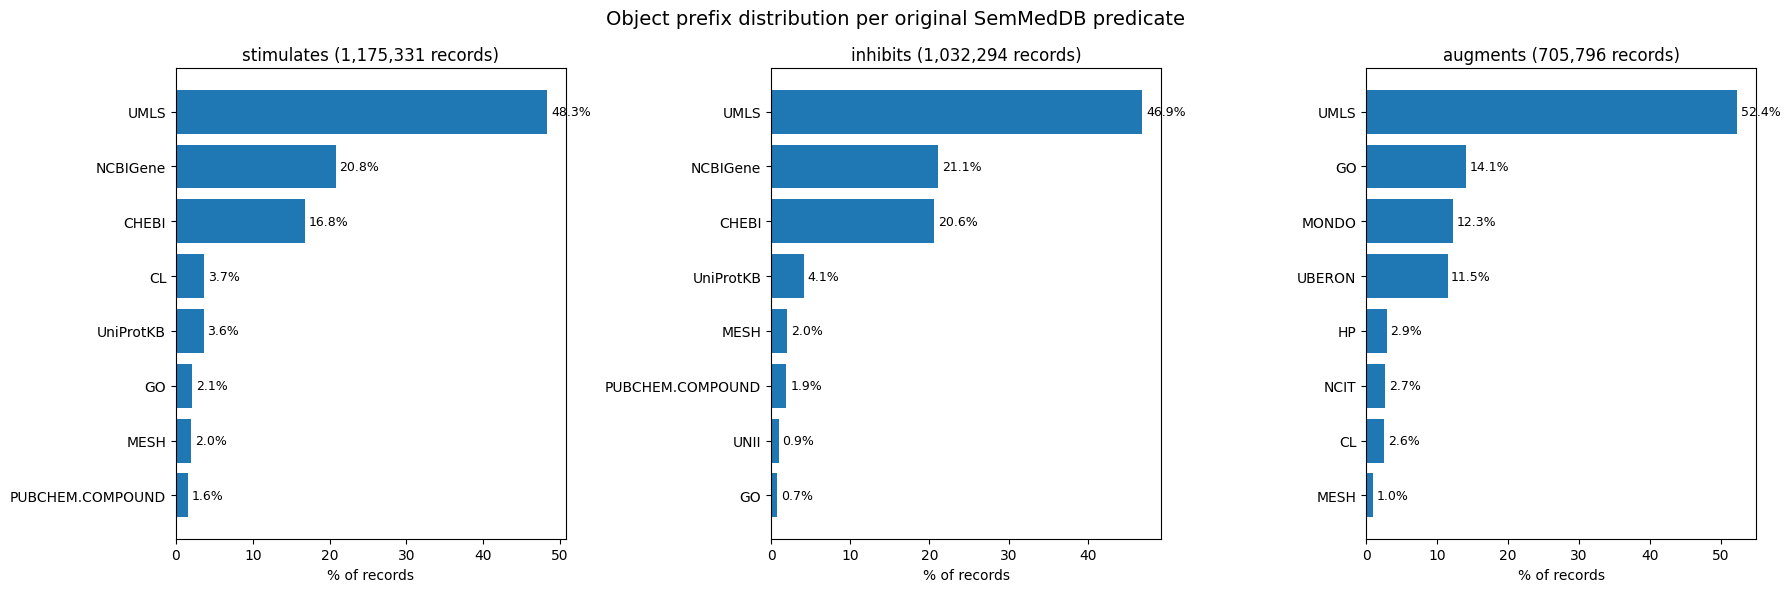

In [15]:
focus_predicates = ["stimulates", "inhibits", "augments"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, pred in enumerate(focus_predicates):
    ax = axes[idx]
    prefix_counts = orig_pred_obj_prefix[pred]
    total = sum(prefix_counts.values())

    # Top 8 prefixes
    top_prefixes = prefix_counts.most_common(8)
    labels = [p for p, _ in top_prefixes]
    values = [c for _, c in top_prefixes]
    pcts = [c / total * 100 for c in values]

    bars = ax.barh(labels[::-1], pcts[::-1])
    ax.set_xlabel("% of records")
    ax.set_title(f"{pred} ({total:,} records)")

    for bar, pct in zip(bars, pcts[::-1]):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f"{pct:.1f}%", va="center", fontsize=9)

plt.suptitle("Object prefix distribution per original SemMedDB predicate", fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
# Detailed tables
for pred in focus_predicates:
    prefix_counts = orig_pred_obj_prefix[pred]
    total = sum(prefix_counts.values())
    print(f"\n{pred.upper()} ({total:,} records):")
    for prefix, count in prefix_counts.most_common(10):
        print(f"  {prefix:20s} {count:>10,}  ({count/total*100:5.1f}%)")


STIMULATES (1,175,331 records):
  UMLS                    568,032  ( 48.3%)
  NCBIGene                244,308  ( 20.8%)
  CHEBI                   197,002  ( 16.8%)
  CL                       43,065  (  3.7%)
  UniProtKB                42,342  (  3.6%)
  GO                       24,676  (  2.1%)
  MESH                     23,066  (  2.0%)
  PUBCHEM.COMPOUND         18,274  (  1.6%)
  UNII                      9,987  (  0.8%)
  MONDO                     2,242  (  0.2%)

INHIBITS (1,032,294 records):
  UMLS                    483,909  ( 46.9%)
  NCBIGene                218,177  ( 21.1%)
  CHEBI                   212,540  ( 20.6%)
  UniProtKB                42,693  (  4.1%)
  MESH                     21,106  (  2.0%)
  PUBCHEM.COMPOUND         19,892  (  1.9%)
  UNII                      9,750  (  0.9%)
  GO                        7,397  (  0.7%)
  NCIT                      5,443  (  0.5%)
  HP                        4,738  (  0.5%)

AUGMENTS (705,796 records):
  UMLS                    3

## 9. Publication Count Distribution
<a id='9-publication-count-distribution'></a>

Our current filter: keep edges with >3 publications (4+).
BTE also applies a per-metatriple threshold (>20 valid docs) which we can't do without semantic types.

In [17]:
# Publication count summary
pub_counts = sorted(pub_count_distribution.keys())
total_recs = sum(pub_count_distribution.values())

# Cumulative from high to low
thresholds = [0, 1, 2, 3, 4, 5, 10, 20, 50, 100]
print("Records remaining at different publication count thresholds:")
print(f"{'Threshold':>12s}  {'Records kept':>15s}  {'% of total':>10s}")
print("-" * 42)

for thresh in thresholds:
    kept = sum(cnt for pc, cnt in pub_count_distribution.items() if pc > thresh)
    print(f"  > {thresh:<8d}  {kept:>15,}  {kept/total_recs*100:>9.1f}%")

print(f"\nCurrent filter: > 3 (keeping 4+)")

Records remaining at different publication count thresholds:
   Threshold     Records kept  % of total
------------------------------------------
  > 0              21,355,695      100.0%
  > 1               6,111,982       28.6%
  > 2               3,466,720       16.2%
  > 3               2,408,315       11.3%
  > 4               1,837,184        8.6%
  > 5               1,481,219        6.9%
  > 10                733,804        3.4%
  > 20                346,038        1.6%
  > 50                119,314        0.6%
  > 100                50,844        0.2%

Current filter: > 3 (keeping 4+)


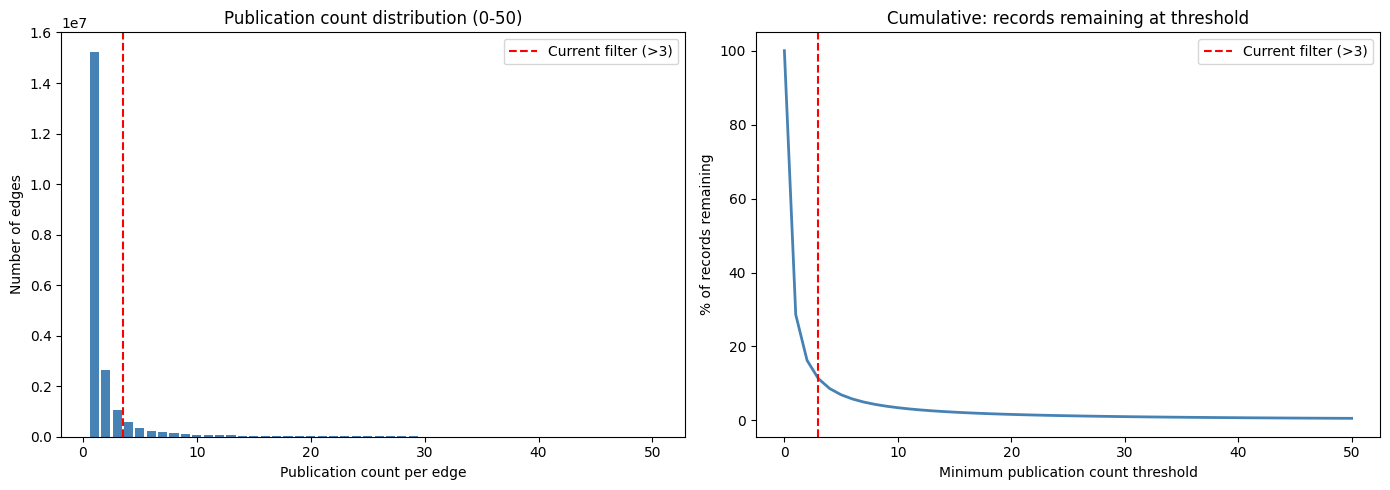

In [18]:
# Distribution plot (capped at 50 for readability)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of pub counts 0-50
plot_counts = {k: v for k, v in pub_count_distribution.items() if k <= 50}
ax1.bar(plot_counts.keys(), plot_counts.values(), color="steelblue")
ax1.set_xlabel("Publication count per edge")
ax1.set_ylabel("Number of edges")
ax1.set_title("Publication count distribution (0-50)")
ax1.axvline(x=3.5, color="red", linestyle="--", label="Current filter (>3)")
ax1.legend()

# Right: cumulative (what % of records remain at each threshold)
x_vals = list(range(0, 51))
y_vals = [
    sum(cnt for pc, cnt in pub_count_distribution.items() if pc > t) / total_recs * 100
    for t in x_vals
]
ax2.plot(x_vals, y_vals, color="steelblue", linewidth=2)
ax2.set_xlabel("Minimum publication count threshold")
ax2.set_ylabel("% of records remaining")
ax2.set_title("Cumulative: records remaining at threshold")
ax2.axvline(x=3, color="red", linestyle="--", label="Current filter (>3)")
ax2.legend()

plt.tight_layout()
plt.show()